## Gaussian Blue Noise Sampling

In this notebook, we generate samples of Gaussian Blue Noise and use that to count linear regions in neural networks. We can then compare the variance properties to the simple iid random sampling (binomial point process).

#### Imports

Standard imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import importlib

Quasi-Monte Carlo libraries:

In [10]:
from matplotlib.collections import PatchCollection
from scipy.stats import qmc

Gaussian Blue Noise files:

In [5]:
import spectrum_nd
import gbn_bounded_current

In [7]:
importlib.reload(gbn_bounded_current)

<module 'gbn_bounded_current' from '/Users/gautamchauhan/Desktop/MSc Project Code/code/gbn_bounded_current.py'>

#### Blue Noise in 2D:

Generate 100 blue noise point sets with 4000 points each:

In [18]:
point_sets = 100
size = 1000
dimensions = 2

In [19]:
blue_noise_points = np.empty((point_sets,size,dimensions))

for i in range(point_sets):
    result = gbn_bounded_current.sample_bounded_gbn(
        point_count=1000,
        dims=2,
        bounds=[[-1,1] for i in range(2)],
        sigma=1,
        iterations=10000,
        seed=i,
    )
    points = result.points
    blue_noise_points[i,:,:] = points

Plot the first set of 2D blue noise points:

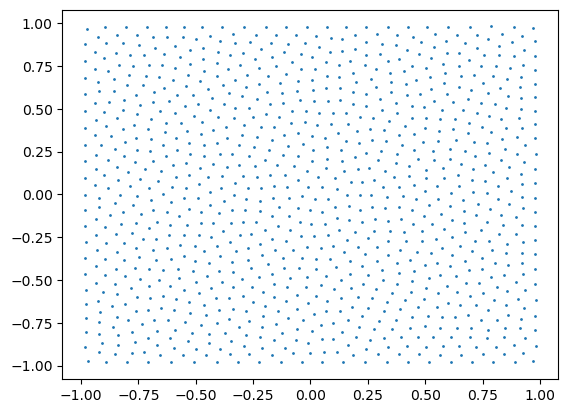

In [20]:
plt.scatter(points[:,0],points[:,1],s=1)

Generate power spectra for each point set and average over the different spectra. Plot the radial component of the power spectrum:

In [21]:
spectra = []
for i in range(point_sets):
    spectrum = spectrum_nd.power_spectrum(blue_noise_points[i,:,:],size=32,device="auto")
    spectra.append(spectrum)

In [31]:
diagonal_magnitudes = [np.sqrt(2*i**2) for i in range(32)]
diagonal_magnitudes = diagonal_magnitudes/max(diagonal_magnitudes)

radial_spectra = np.empty((point_sets,32))
for i in range(point_sets):
    radial_spectra[i,:] = np.array([spectra[i][j,j] for j in range(32,64)])
mean_spectrum = np.mean(radial_spectra,axis=0)

Text(0, 0.5, 'Amplitude')

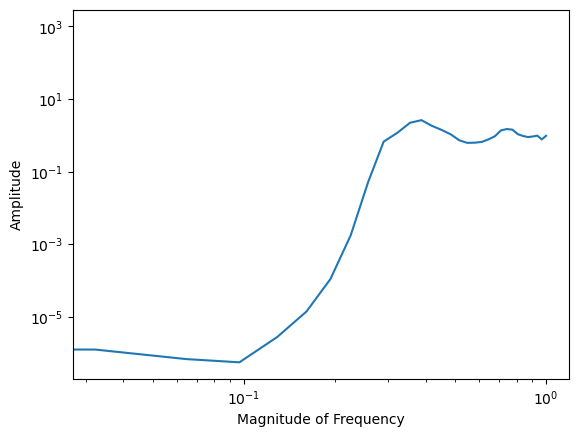

In [32]:
plt.loglog(diagonal_magnitudes,mean_spectrum)
plt.xlabel("Magnitude of Frequency")
plt.ylabel("Amplitude")

#### Blue Noise in 3D:

In [34]:
dimensions=3
blue_noise_points_3D = np.empty((point_sets,size,dimensions))

for i in range(point_sets):
    result = gbn_bounded_current.sample_bounded_gbn(
        point_count=1000,
        dims=3,
        bounds=[[-1,1] for i in range(3)],
        sigma=1,
        iterations=10000,
        seed=i,
    )
    points = result.points
    blue_noise_points_3D[i,:,:] = points

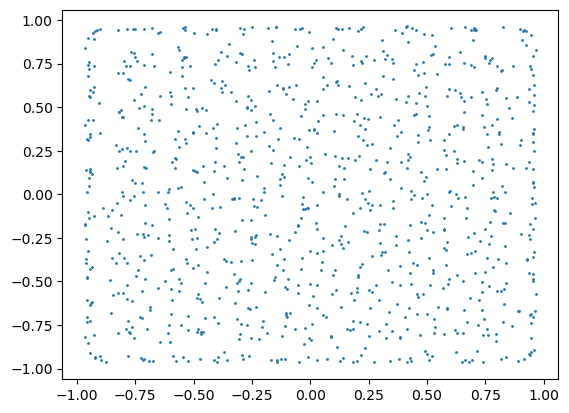

In [35]:
plt.scatter(points[:,0],points[:,1],s=1)

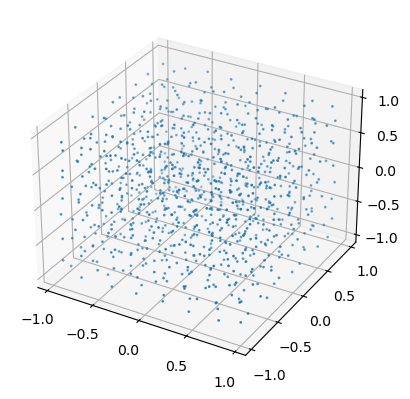

In [36]:
fig = plt.figure()
axs = fig.add_subplot(projection="3d")
axs.scatter(points[:,0],points[:,1],points[:,2],s=1)

In [38]:
spectra = []
for i in range(point_sets):
    spectrum = spectrum_nd.power_spectrum(blue_noise_points_3D[i,:,:],size=32,device="auto")
    spectra.append(spectrum)

In [41]:
diagonal_magnitudes = [np.sqrt(3*i**2) for i in range(32)]
diagonal_magnitudes = diagonal_magnitudes/max(diagonal_magnitudes)

radial_spectra = np.empty((point_sets,32))
for i in range(point_sets):
    radial_spectra[i,:] = np.array([spectra[i][j,j,j] for j in range(32,64)])
mean_spectrum = np.mean(radial_spectra,axis=0)

Text(0, 0.5, 'Amplitude')

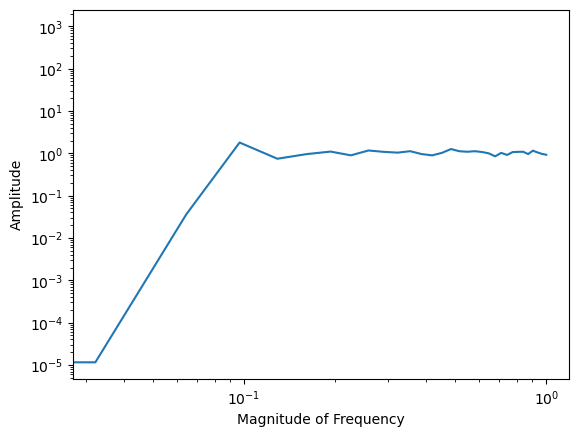

In [42]:
plt.loglog(diagonal_magnitudes,mean_spectrum)
plt.xlabel("Magnitude of Frequency")
plt.ylabel("Amplitude")

#### Comments: 2D and 3D Blue Noise

1. Quality appears to decrease as dimension increases, which is not what is shown in their paper
    - This could be because the codex code is not correct
    - Alternatively, this could be because we are using a bounded domain instead of a toroidal domain

2. The time complexity of generating Gaussian Blue Noise is $O(dn^2)$ (linear in number of dimensions but quadratic in number of points)

#### Alternative 1: Poisson Disk Sampling

If we set $r = n^{-\frac{1}{d}}$, then the points roughly cover the space without leaving large unsampled gaps.

Time complexity is $O(n)$ with the number of samples.

Investigate time complexity with dimension by plotting runtime and dimension:

In [79]:
dimensions = [2,3,4,5,6]
n = 1700
runtimes = []

for dimension in dimensions:
    start_time = time.time()
    radius = n**(-1/dimension)
    engine = qmc.PoissonDisk(d=dimension, radius=radius, seed=1)
    sample = engine.random(n)
    end_time = time.time()
    runtimes.append(end_time-start_time)

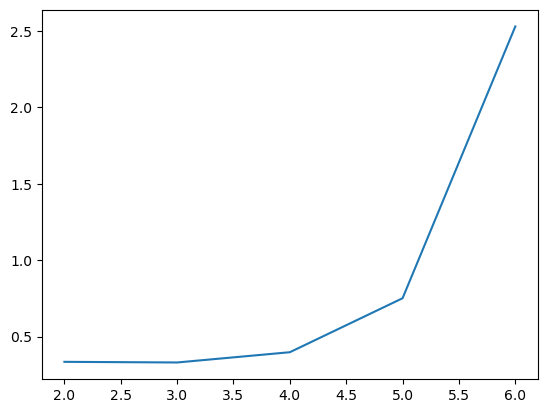

In [82]:
plt.plot(dimensions,runtimes)

#### Alternative 2: Halton Sequences

In [71]:
sampler = qmc.Halton(d=2, scramble=True,seed=100)
sample = sampler.random(n=1000)

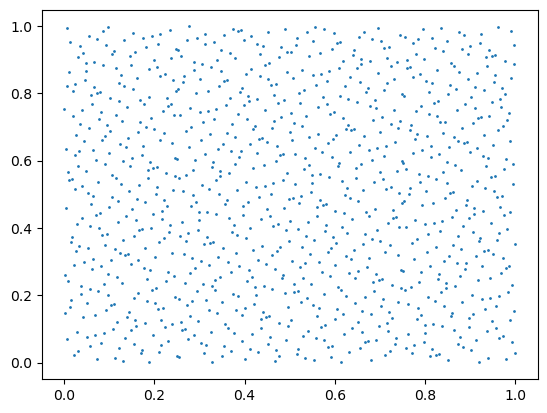

In [72]:
plt.scatter(sample[:,0],sample[:,1],s=1)